# Livrable 2 :

In [1]:
import tensorflow as tf
import numpy as np
import os
import sys
from tensorflow import keras

project_root = os.path.abspath(os.path.join(".."))  # One level up from current script
if project_root not in sys.path:
    sys.path.append(project_root)

from src.model_loader import ModelLoader
from src.data_loader import DataLoader
from src.utils import get_confusion_matrix, get_classification_report

print(tf.__version__)

2025-04-18 10:35:42.816678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744965342.872685   25310 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744965342.886468   25310 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744965342.941727   25310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744965342.941784   25310 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1744965342.941786   25310 computation_placer.cc:177] computation placer alr

2.19.0


## Généation du dataset de photos

In [2]:
data_loader = DataLoader()
train_ds, test_ds, val_ds = data_loader.load_unique_dataset(folder_name="Photo")


Photo Dataset size: 9993


I0000 00:00:1744965349.382184   25310 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## Bruitage du dataset

In [ ]:
# noisy_train_ds = data_loader.add_noise_to_dataset(train_ds)
# noisy_val_ds = data_loader.add_noise_to_dataset(val_ds)
# noisy_test_ds = data_loader.add_noise_to_dataset(test_ds)

noisy_train_ds = data_loader.add_noise_to_dataset(
    dataset=train_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.4
)
noisy_val_ds = data_loader.add_noise_to_dataset(
    dataset=val_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.4  
)
noisy_test_ds = data_loader.add_noise_to_dataset(
    dataset=test_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.7
)


In [49]:
noisy_test_ds = data_loader.add_noise_to_dataset(
    dataset=test_ds,
    noise_factor_range=(0.1, 0.6),
    pixel_noise_prob=0.7
)

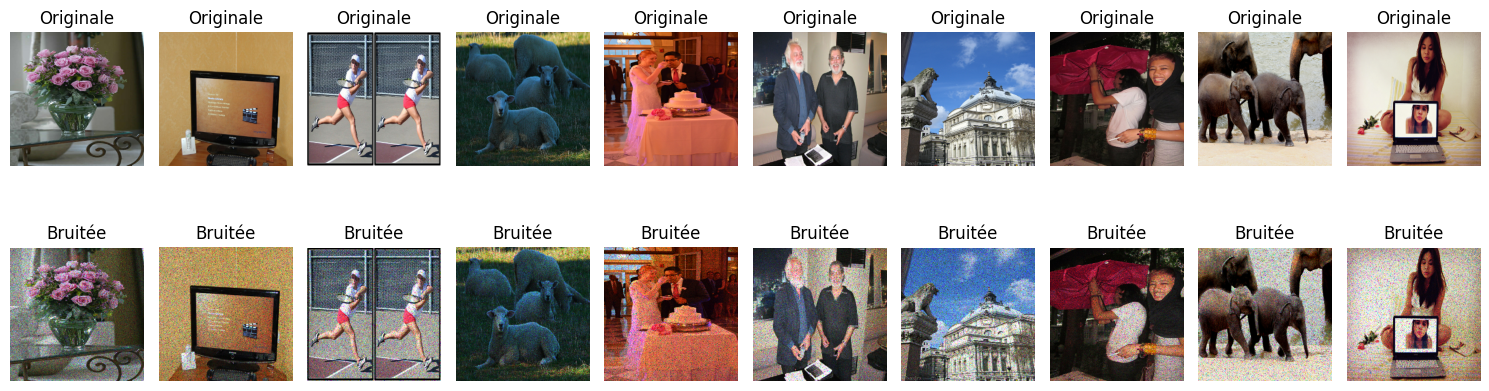

In [35]:
from src.utils import show_clean_and_noisy_images

show_clean_and_noisy_images(train_ds, noisy_train_ds, max_images=10)

In [20]:
from keras.layers import Input, Conv2D, BatchNormalization, LeakyReLU
from keras.models import Model

encoder_inputs = Input(shape=(256, 256, 3))  # Image RGB 256x256

# --- Block 1 ---
x1 = Conv2D(32, (3, 3), strides=2, padding='same')(encoder_inputs)  # (128, 128, 32)
x1 = BatchNormalization()(x1)
x1 = LeakyReLU()(x1)

# --- Block 2 ---
x2 = Conv2D(64, (3, 3), strides=2, padding='same')(x1)  # (64, 64, 64)
x2 = BatchNormalization()(x2)
x2 = LeakyReLU()(x2)

# --- Block 3 ---
x3 = Conv2D(128, (3, 3), strides=2, padding='same')(x2)  # (32, 32, 128)
x3 = BatchNormalization()(x3)
x3 = LeakyReLU()(x3)

# --- Block 4 ---
x4 = Conv2D(256, (3, 3), strides=2, padding='same')(x3)  # (16, 16, 256)
x4 = BatchNormalization()(x4)
x4 = LeakyReLU()(x4)

# --- Block 5 ---
x5 = Conv2D(256, (3, 3), strides=2, padding='same')(x4)  # (8, 8, 256)
x5 = BatchNormalization()(x5)
x5 = LeakyReLU()(x5)

# Sorties : encoder_output + features pour skip connections
encoder = Model(inputs=encoder_inputs, outputs=[x5, x4, x3, x2, x1], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 981,440 (3.74 MB)

 Trainable params: 979,968 (3.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [21]:
from keras.layers import Conv2DTranspose, Concatenate, Input, BatchNormalization, LeakyReLU
from keras.models import Model

# Entrées : latent + les 4 couches skip
latent_input = Input(shape=(8, 8, 256))     # Sortie finale de l'encodeur
skip4 = Input(shape=(16, 16, 256))
skip3 = Input(shape=(32, 32, 128))
skip2 = Input(shape=(64, 64, 64))
skip1 = Input(shape=(128, 128, 32))

x = latent_input

# Decode Block 1
x = Conv2DTranspose(256, (3, 3), strides=2, padding='same')(x)  # (16, 16, 256)
x = Concatenate()([x, skip4])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 2
x = Conv2DTranspose(128, (3, 3), strides=2, padding='same')(x)  # (32, 32, 128)
x = Concatenate()([x, skip3])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 3
x = Conv2DTranspose(64, (3, 3), strides=2, padding='same')(x)  # (64, 64, 64)
x = Concatenate()([x, skip2])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 4
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (128, 128, 32)
x = Concatenate()([x, skip1])
x = BatchNormalization()(x)
x = LeakyReLU()(x)

# Decode Block 5 - reconstruction finale
x = Conv2DTranspose(32, (3, 3), strides=2, padding='same')(x)  # (256, 256, 32)
decoder_output = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

# Modèle
decoder = Model(inputs=[latent_input, skip4, skip3, skip2, skip1], outputs=decoder_output, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 8, 8, 256) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 16, 16,    │    590,080 │ input_layer_8[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 16, 16,    │          0 │ -                 │
│ (InputLayer)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      2,048 │ concatenate_4[0]… │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_19      │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 32, 32,    │    589,952 │ leaky_re_lu_19[0… │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_10      │ (None, 32, 32,    │          0 │ -                 │
│ (InputLayer)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ concatenate_5[0]… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_20      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_7  │ (None, 64, 64,    │    147,520 │ leaky_re_lu_20[0… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 64, 64,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ input_layer_11[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ concatenate_6[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_21      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 128, 128,  │     36,896 │ leaky_re_lu_21[0

 Total params: 1,387,619 (5.29 MB)

 Trainable params: 1,385,699 (5.29 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [22]:
import tensorflow as tf

# -- Metrics Custom --
def ssim_metric(y_true, y_pred):
    # SSIM attend des valeurs entre [0, 1], donc il est important de s'assurer que les images sont dans cette plage.
    y_true = tf.clip_by_value(y_true, 0.0, 1.0)  # Pour être sûr que les valeurs sont entre [0, 1]
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)  # Pour être sûr que les valeurs sont entre [0, 1]
    
    # Calcul du SSIM sur les images RGB
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))  # max_val=1.0 pour les images normalisées

def psnr_metric(y_true, y_pred):
    # PSNR attend des valeurs entre [0, 1], donc on s'assure que les images sont dans cette plage.
    y_true = tf.clip_by_value(y_true, 0.0, 1.0)  # Normalisation entre [0, 1]
    y_pred = tf.clip_by_value(y_pred, 0.0, 1.0)  # Normalisation entre [0, 1]
    
    # Calcul du PSNR sur les images RGB
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))  # max_val=1.0 pour les images normalisées



In [23]:
from tensorflow.keras.models import Model

encoder_outputs = encoder(encoder_inputs)
decoded_img = decoder(encoder_outputs)

autoencoder = Model(inputs=encoder_inputs, outputs=decoded_img)

# Compilation de l'autoencodeur
autoencoder.compile(optimizer="adam", loss="mae", metrics=['mae', ssim_metric, psnr_metric])

# Résumé du modèle
autoencoder.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder             │ [(None, 8, 8,     │    981,440 │ input_layer_7[0]… │
│ (Functional)        │ 256), (None, 16,  │            │                   │
│                     │ 16, 256), (None,  │            │                   │
│                     │ 32, 32, 128),     │            │                   │
│                     │ (None, 64, 64,    │            │                   │
│                     │ 64), (None, 128,  │            │                   │
│                     │ 128, 32)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder             │ (None, 256, 256,  │  1,387,619 │ encoder[0][0],    │
│ (Functional)        │ 3)                │            │ encoder[0][1],    │
│                     │                   │            │ encoder[0][2],    │
│                     │                   │            │ encoder[0][3],    │
│                     │                   │            │ encoder[0][4]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,369,059 (9.04 MB)

 Trainable params: 2,365,667 (9.02 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [24]:
@tf.autograph.experimental.do_not_convert
def make_autoencoder_dataset(input_ds, target_ds):
    return tf.data.Dataset.zip((input_ds.map(lambda x, y: x), target_ds.map(lambda x, y: x)))

In [25]:
train_autoenc_ds = make_autoencoder_dataset(noisy_train_ds, train_ds)
val_autoenc_ds = make_autoencoder_dataset(noisy_val_ds, val_ds)

In [26]:
# Train the model
with tf.device("/gpu:0"):
    history = autoencoder.fit(train_autoenc_ds,
                    epochs=10,
                    batch_size= 32,
                    shuffle= True,
                    validation_data=val_autoenc_ds,
                    verbose=1
                   )

Epoch 1/10


2025-04-18 10:39:21.774051: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-04-18 10:39:21.774368: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1744965563.321228   25424 service.cc:152] XLA service 0x7f2f94002860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744965563.321393   25424 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3070 Ti Laptop GPU, Compute Capability 8.6
20

199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0791 - mae: 0.0791 - psnr_metric: 20.4771 - ssim_metric: 0.4848

2025-04-18 10:40:43.834398: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-04-18 10:40:43.834893: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-04-18 10:40:43.835127: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-04-18 10:40:43.835327: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert
2025-04-18 10:40:43.838415: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert/Assert
2025-04-18 10:40:43.838574: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator PSNR/Assert_1/Assert
2025-04-18 10:40:59.535455: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 16 bytes spill stores, 16 bytes spi

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.0790 - mae: 0.0790 - psnr_metric: 20.4855 - ssim_metric: 0.4853

...

200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - loss: 0.0472 - mae: 0.0472 - psnr_metric: 24.0274 - ssim_metric: 0.6737 - val_loss: 0.0449 - val_mae: 0.0449 - val_psnr_metric: 24.3146 - val_ssim_metric: 0.6532
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0459 - mae: 0.0459 - psnr_metric: 24.3200 - ssim_metric: 0.6855

2025-04-18 10:43:34.800892: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-04-18 10:43:34.803866: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - loss: 0.0459 - mae: 0.0459 - psnr_metric: 24.3192 - ssim_metric: 0.6854 - val_loss: 0.0445 - val_mae: 0.0445 - val_psnr_metric: 24.3408 - val_ssim_metric: 0.6758
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - loss: 0.0455 - mae: 0.0455 - psnr_metric: 24.3373 - ssim_metric: 0.6892 - val_loss: 0.0492 - val_mae: 0.0492 - val_psnr_metric: 23.5763 - val_ssim_metric: 0.6359
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0458 - mae: 0.0458 - psnr_metric: 24.2816 - ssim_metric: 0.6865

2025-04-18 10:44:30.216669: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 25166080 bytes after encountering the first element of size 25166080 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2025-04-18 10:44:30.218519: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 50331648 bytes after encountering the first element of size 50331648 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


200/200 ━━━━━━━━━━━━━━━━━━━━ 28s 136ms/step - loss: 0.0458 - mae: 0.0458 - psnr_metric: 24.2817 - ssim_metric: 0.6865 - val_loss: 0.0446 - val_mae: 0.0446 - val_psnr_metric: 24.4051 - val_ssim_metric: 0.6703
Epoch 9/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 132ms/step - loss: 0.0440 - mae: 0.0440 - psnr_metric: 24.5946 - ssim_metric: 0.7020 - val_loss: 0.0442 - val_mae: 0.0442 - val_psnr_metric: 24.5021 - val_ssim_metric: 0.6655
Epoch 10/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 130ms/step - loss: 0.0436 - mae: 0.0436 - psnr_metric: 24.6894 - ssim_metric: 0.7050 - val_loss: 0.0460 - val_mae: 0.0460 - val_psnr_metric: 24.2247 - val_ssim_metric: 0.6677


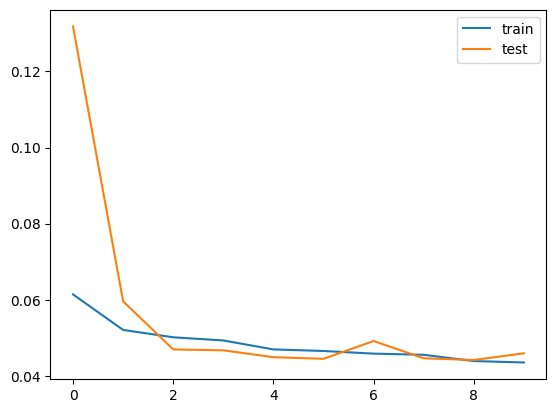

In [27]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()


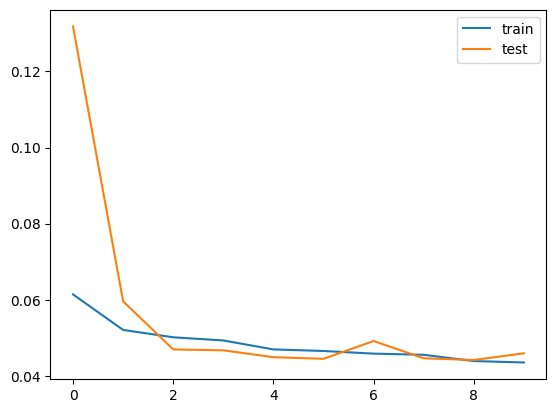

In [28]:

plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='test')
plt.legend()

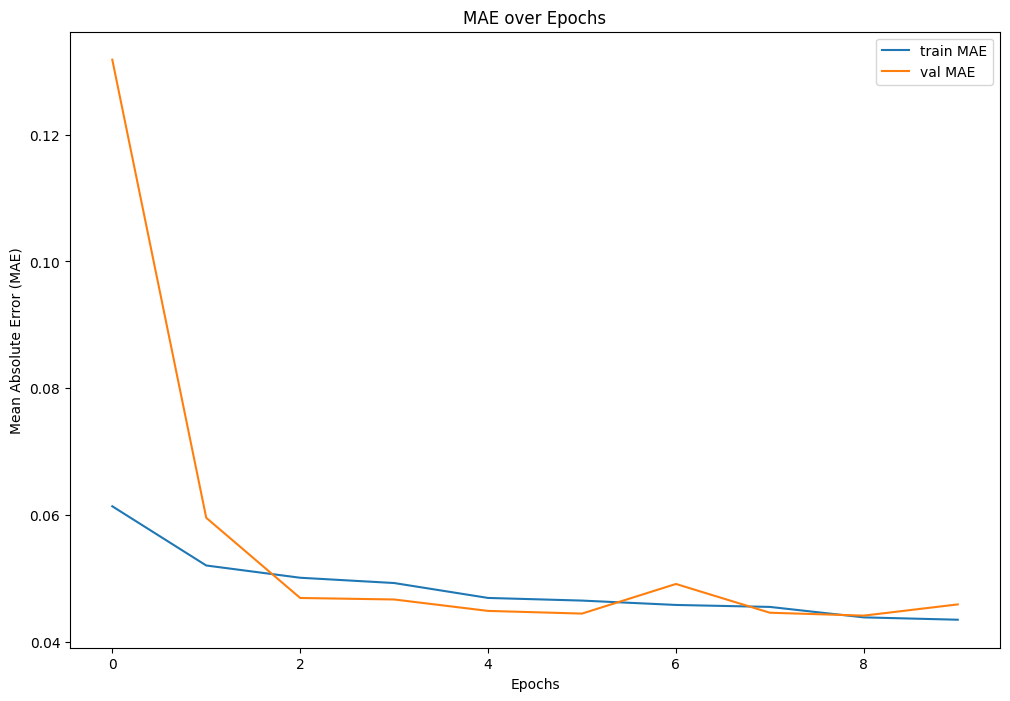

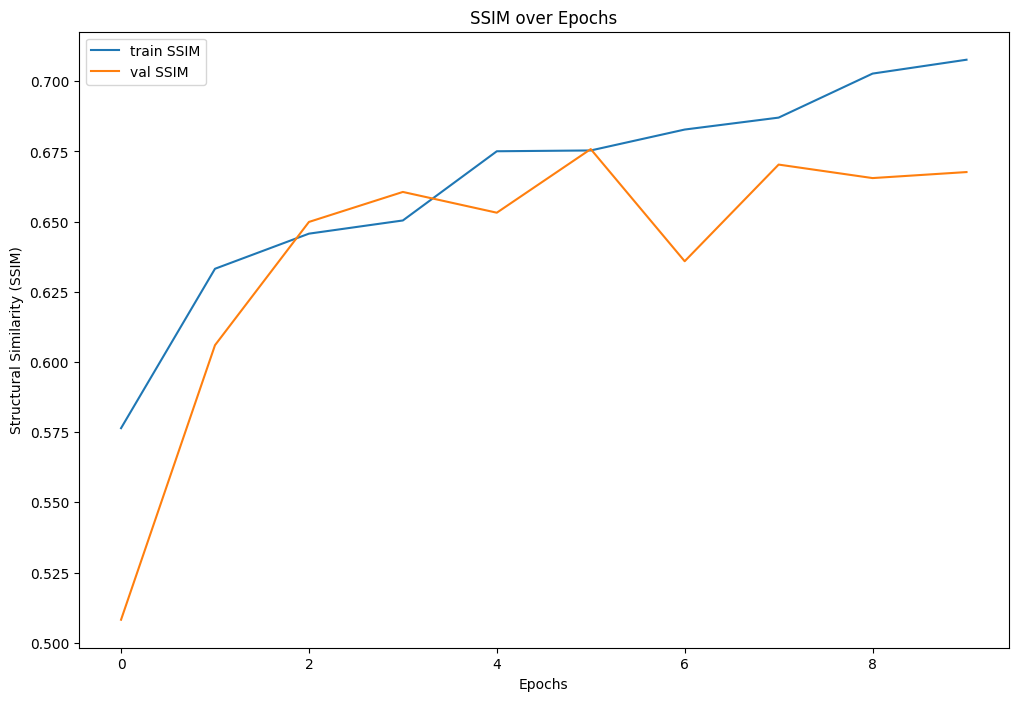

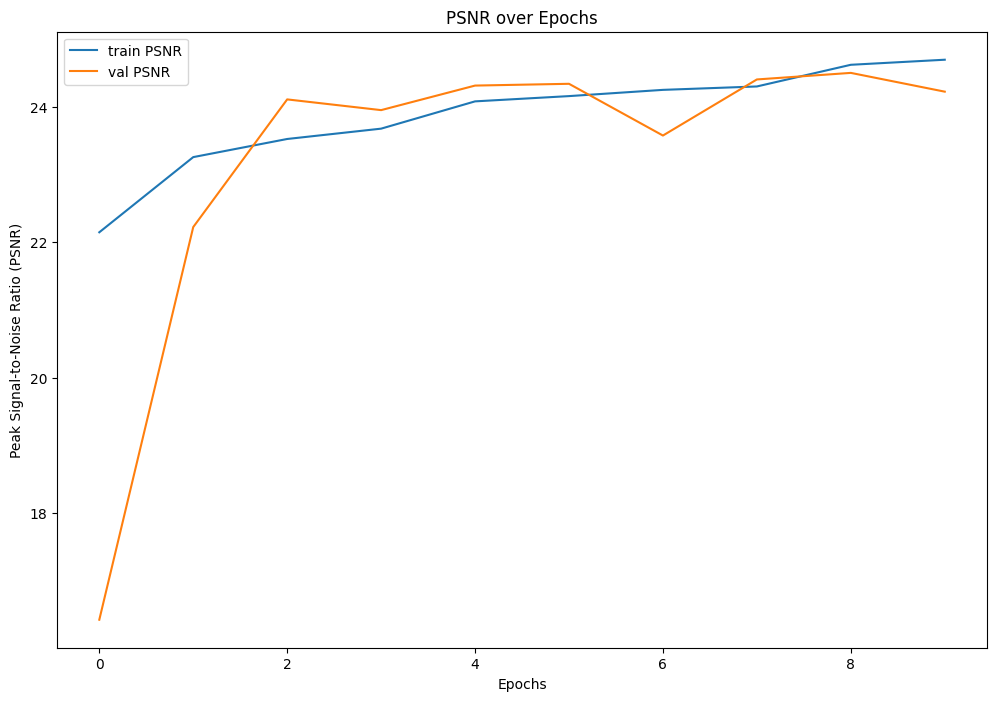

In [29]:
import matplotlib.pyplot as plt

# Tracer l'évolution de MAE
plt.figure(figsize=(12, 8))
plt.plot(history.history['mae'], label='train MAE')
plt.plot(history.history['val_mae'], label='val MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('MAE over Epochs')
plt.legend()
plt.show()

# Tracer l'évolution de SSIM
plt.figure(figsize=(12, 8))
plt.plot(history.history['ssim_metric'], label='train SSIM')
plt.plot(history.history['val_ssim_metric'], label='val SSIM')
plt.xlabel('Epochs')
plt.ylabel('Structural Similarity (SSIM)')
plt.title('SSIM over Epochs')
plt.legend()
plt.show()

# Tracer l'évolution de PSNR
plt.figure(figsize=(12, 8))
plt.plot(history.history['psnr_metric'], label='train PSNR')
plt.plot(history.history['val_psnr_metric'], label='val PSNR')
plt.xlabel('Epochs')
plt.ylabel('Peak Signal-to-Noise Ratio (PSNR)')
plt.title('PSNR over Epochs')
plt.legend()
plt.show()

In [30]:
import cv2

def variance_of_laplacian_rgb(image_rgb):
    image_rgb = np.array(image_rgb)  # Assure que c'est un array numpy
    if image_rgb.shape[-1] == 3:
        gray = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image_rgb * 255).astype(np.uint8)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    return laplacian.var()

def tenengrad_rgb(image_rgb):
    image_rgb = np.array(image_rgb)  # Assure que c'est un array numpy
    if image_rgb.shape[-1] == 3:
        gray = cv2.cvtColor((image_rgb * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    else:
        gray = (image_rgb * 255).astype(np.uint8)
    gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)
    gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1)
    magnitude = np.sqrt(gx**2 + gy**2)
    return np.mean(magnitude)

In [ ]:
import matplotlib.pyplot as plt


# Fonction SSIM
def ssim_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))

# Fonction PSNR
def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

# Fonction MAE
def mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def show_full_prediction_metrics(noisy_dataset, clean_dataset, model, n=10):
    import matplotlib.pyplot as plt

    # Toutes les métriques globales
    lap_sharpness_list = []
    ten_sharpness_list = []
    mae_list = []
    ssim_list = []
    psnr_list = []

    all_noisy = []
    all_clean = []
    all_decoded = []

    print("📊 Prédiction sur l'ensemble du dataset...")
    for (noisy_batch, _), (clean_batch, _) in zip(noisy_dataset, clean_dataset):
        decoded_batch = model.predict(noisy_batch, verbose=0)
        for i in range(len(noisy_batch)):
            noisy = noisy_batch[i].numpy()
            original = clean_batch[i].numpy()
            decoded = decoded_batch[i]

            # Métriques
            sharp_orig_lap = variance_of_laplacian_rgb(original)
            sharp_dec_lap = variance_of_laplacian_rgb(decoded)

            sharp_orig_ten = tenengrad_rgb(original)
            sharp_dec_ten = tenengrad_rgb(decoded)

            ssim_val = ssim_metric(original, decoded).numpy()
            psnr_val = psnr_metric(original, decoded).numpy()
            mae_val = mae_metric(original, decoded).numpy()

            lap_percent = (sharp_dec_lap / sharp_orig_lap) * 100 if sharp_orig_lap != 0 else 0
            ten_percent = (sharp_dec_ten / sharp_orig_ten) * 100 if sharp_orig_ten != 0 else 0

            lap_sharpness_list.append(lap_percent)
            ten_sharpness_list.append(ten_percent)
            mae_list.append(mae_val)
            ssim_list.append(ssim_val)
            psnr_list.append(psnr_val)

            print("lap list", lap_sharpness_list)
            print("ten list", ten_sharpness_list)
            
            # Stocker pour affichage des exemples
            if len(all_decoded) < n:
                all_noisy.append(noisy)
                all_clean.append(original)
                all_decoded.append(decoded)

    # --- Affichage de n exemples ---
    plt.figure(figsize=(18, 12))
    for i in range(n):
        noisy = all_noisy[i]
        original = all_clean[i]
        decoded = all_decoded[i]

        sharp_orig_lap = variance_of_laplacian_rgb(original)
        sharp_dec_lap = variance_of_laplacian_rgb(decoded)

        sharp_orig_ten = tenengrad_rgb(original)
        sharp_dec_ten = tenengrad_rgb(decoded)

        ssim_val = ssim_metric(original, decoded).numpy()
        psnr_val = psnr_metric(original, decoded).numpy()
        mae_val = mae_metric(original, decoded).numpy()

        sharpness_percent_lap = (sharp_dec_lap / sharp_orig_lap) * 100 if sharp_orig_lap != 0 else 0
        sharpness_percent_ten = (sharp_dec_ten / sharp_orig_ten) * 100 if sharp_orig_ten != 0 else 0

        # Image bruitée
        ax = plt.subplot(5, n, i + 1)
        plt.imshow(noisy)
        plt.title("Bruitée")
        plt.axis("off")

        # Originale
        ax = plt.subplot(5, n, n + i + 1)
        plt.imshow(original)
        plt.title(f"Originale\nLap: {sharp_orig_lap:.1f} | Ten: {sharp_orig_ten:.1f}")
        plt.axis("off")

        # Reconstruite
        ax = plt.subplot(5, n, 2 * n + i + 1)
        plt.imshow(decoded)
        plt.title(
            f"Reconstruit\nLap: {sharp_dec_lap:.1f} ({sharpness_percent_lap:.1f}%)\n"
            f"Ten: {sharp_dec_ten:.1f} ({sharpness_percent_ten:.1f}%)\n"
            f"SSIM: {ssim_val:.3f} | PSNR: {psnr_val:.1f}\nMAE: {mae_val:.4f}"
        )
        plt.axis("off")

    # --- Moyennes globales ---
    avg_lap = sum(sharpness_percent_lap) / len(lap_sharpness_list)
    avg_ten = sum(sharpness_percent_ten) / len(ten_sharpness_list)
    avg_mae = sum(mae_list) / len(mae_list)
    avg_ssim = sum(ssim_list) / len(ssim_list)
    avg_psnr = sum(psnr_list) / len(psnr_list)

    ax = plt.subplot(5, 1, 5)
    plt.axis('off')
    plt.text(
        0.5, 0.5,
        (
            f"**Moyennes globales sur {len(lap_sharpness_list)} images**\n\n"
            f"Netteté Laplacian: {avg_lap:.2f}% | Tenengrad: {avg_ten:.2f}%\n"
            f"MAE: {avg_mae:.4f} | SSIM: {avg_ssim:.3f} | PSNR: {avg_psnr:.1f} dB"
        ),
        fontsize=16, ha='center', va='center', fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


📊 Prédiction sur l'ensemble du dataset...


2025-04-18 11:02:11.970428: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


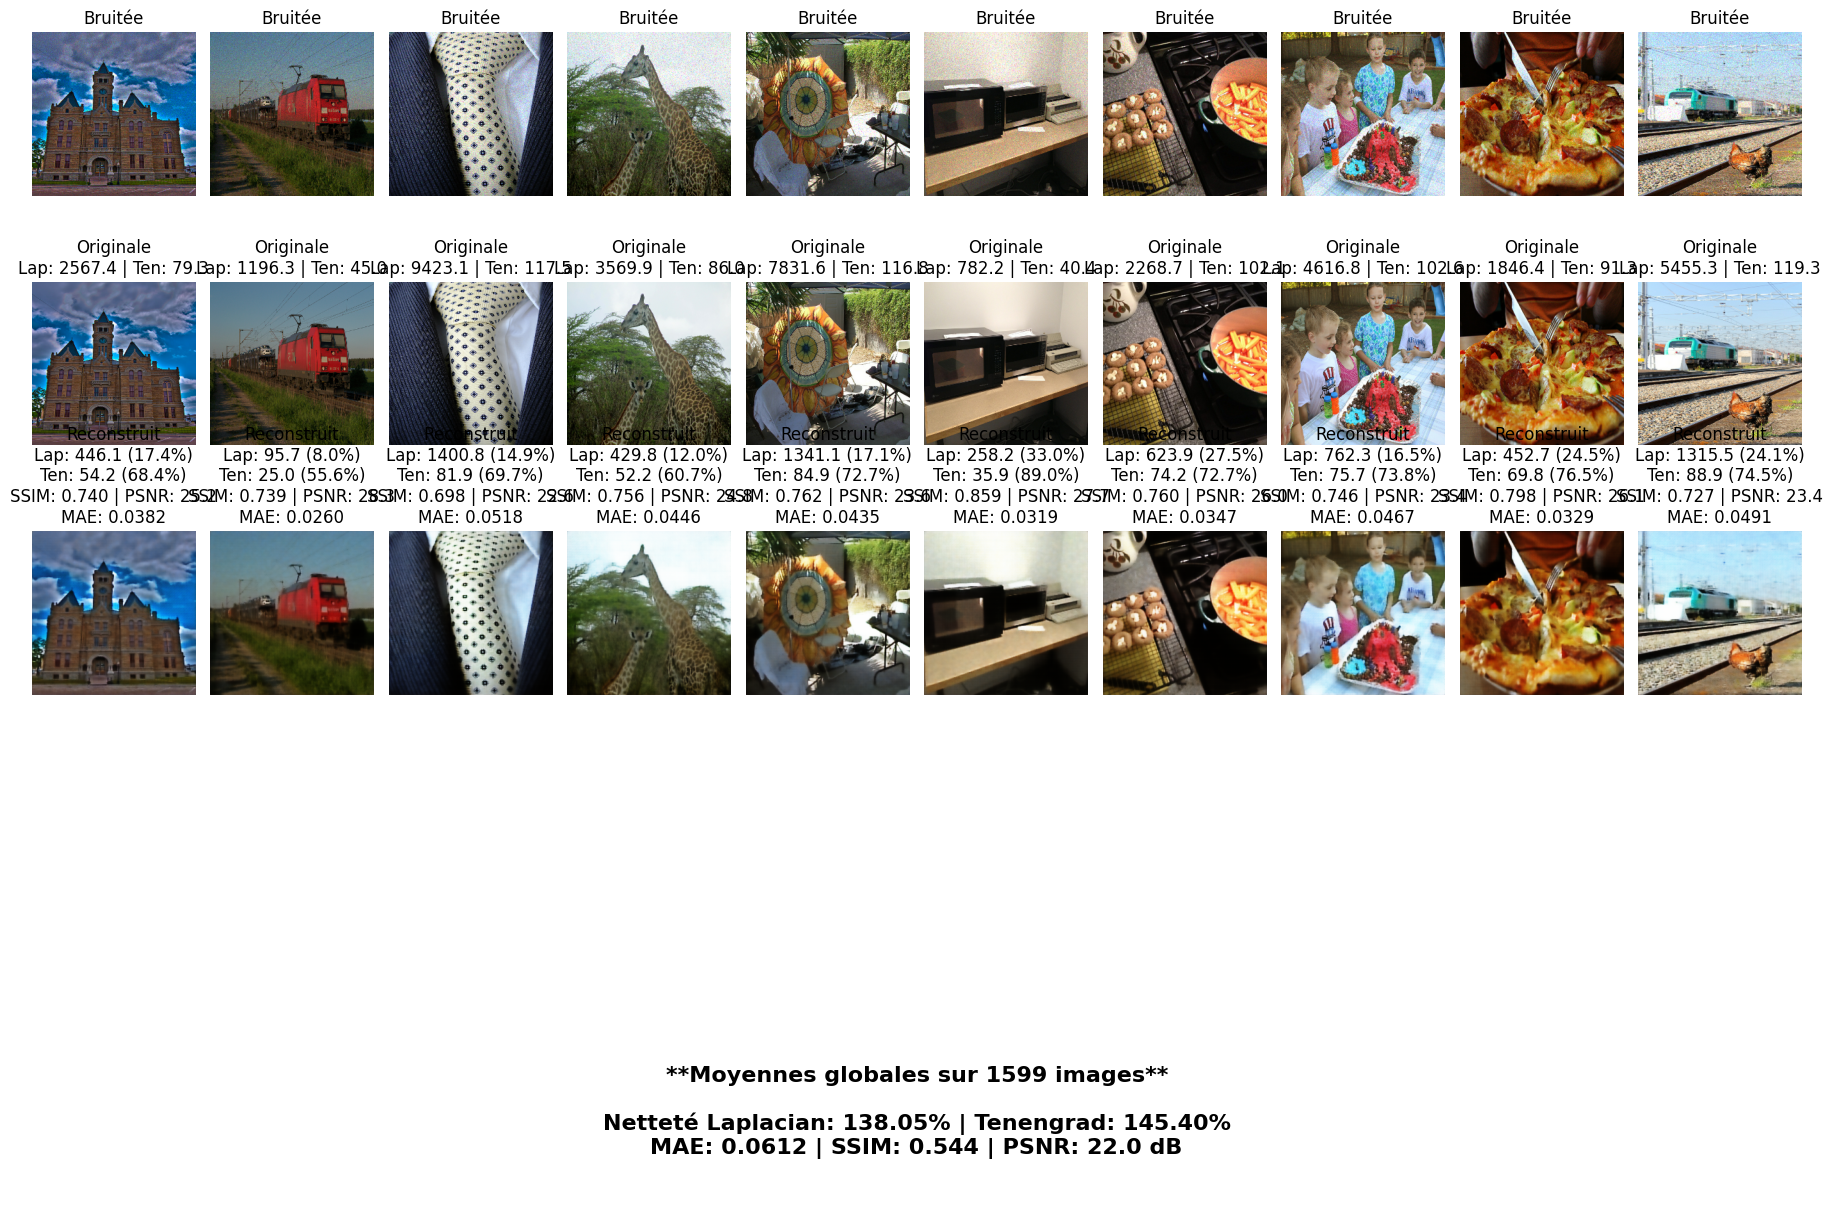

In [50]:
show_full_prediction_metrics(noisy_test_ds, test_ds, autoencoder)